# 0. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:

# this is actually file and path
file_path = 'churn-bigml-80.csv'

# Read the CSV file
df = pd.read_csv(file_path)

# Display the header
print(df.head())


  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

# 1. Data Cleaning

## 1.1 Missing Values

In [3]:
# Summarize Missing Values
missing_summary = df.isnull().sum()
print("\nSummary of Missing Values:\n", missing_summary)



Summary of Missing Values:
 State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


## 1.2 Duplicates

In [4]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2661    False
2662    False
2663    False
2664    False
2665    False
Length: 2666, dtype: bool

In [5]:
df[df.duplicated()]

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn


In [6]:
# df = df.drop_duplicates()

No need for duplicates cleaning.

## 1.3 Dirty Data 

check if data conforms to format definitions 

In [7]:
# 1.3 Check if data conforms to format definitions (schema / data types)
# Expected schema: State=str, Account length=int, Area code=int, International plan=Yes/No,
# Voice mail plan=Yes/No, Number vmail messages=int, Total *_minutes=float, Total *_calls=int,
# Total *_charge=float, Customer service calls=int, Churn=True/False (string)

expected_dtypes = {
    'State': 'object',
    'Account length': 'int64',
    'Area code': 'int64',
    'International plan': 'object',
    'Voice mail plan': 'object',
    'Number vmail messages': 'int64',
    'Total day minutes': 'float64',
    'Total day calls': 'int64',
    'Total day charge': 'float64',
    'Total eve minutes': 'float64',
    'Total eve calls': 'int64',
    'Total eve charge': 'float64',
    'Total night minutes': 'float64',
    'Total night calls': 'int64',
    'Total night charge': 'float64',
    'Total intl minutes': 'float64',
    'Total intl calls': 'int64',
    'Total intl charge': 'float64',
    'Customer service calls': 'int64',
    'Churn': 'object'
}

print("=== 1. Data type conformance ===\n")
issues_dtype = []
for col in expected_dtypes:
    if col not in df.columns:
        issues_dtype.append((col, "MISSING COLUMN", None))
        continue
    actual = str(df[col].dtype)
    expected = expected_dtypes[col]
    # Allow both int64 and int32 as integer, float64 and float32 as float
    ok = (actual == expected or
          (expected == 'int64' and actual in ('int64', 'int32')) or
          (expected == 'float64' and actual in ('float64', 'float32')))
    if not ok:
        issues_dtype.append((col, expected, actual))

if not issues_dtype:
    print("All columns have expected data types.")
else:
    for col, exp, act in issues_dtype:
        print(f"  {col}: expected {exp}, got {act or 'N/A'}")

# 2. Categorical value conformance (binary Yes/No, True/False)
print("\n=== 2. Categorical value conformance ===\n")
binary_checks = {
    'International plan': ['Yes', 'No'],
    'Voice mail plan': ['Yes', 'No'],
}
for col, allowed in binary_checks.items():
    if col not in df.columns:
        continue
    uniq = df[col].dropna().astype(str).unique().tolist()
    invalid = [v for v in uniq if v not in allowed]
    if invalid:
        print(f"  {col}: allowed {allowed}, found unexpected values: {invalid}")
    else:
        print(f"  {col}: OK (values in {allowed})")

# Churn: expect True/False (may be string or bool)
if 'Churn' in df.columns:
    churn_vals = df['Churn'].dropna().astype(str).unique().tolist()
    allowed_churn = ['True', 'False', 'true', 'false']
    invalid_churn = [v for v in churn_vals if v not in allowed_churn]
    if invalid_churn:
        print(f"  Churn: allowed True/False, found: {invalid_churn}")
    else:
        print(f"  Churn: OK (values in True/False)")

# 3. Numeric ranges (e.g. no negative counts)
print("\n=== 3. Sanity checks (e.g. non-negative counts) ===\n")
count_cols = [c for c in df.columns if 'calls' in c or 'messages' in c or c == 'Account length']
for col in count_cols:
    if col not in df.columns:
        continue
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f"  {col}: {neg} negative value(s) found.")
if not any((df[c] < 0).sum() > 0 for c in count_cols if c in df.columns):
    print("  All count-like columns are non-negative.")

=== 1. Data type conformance ===

  Churn: expected object, got bool

=== 2. Categorical value conformance ===

  International plan: OK (values in ['Yes', 'No'])
  Voice mail plan: OK (values in ['Yes', 'No'])
  Churn: OK (values in True/False)

=== 3. Sanity checks (e.g. non-negative counts) ===

  All count-like columns are non-negative.


## 1.4 Outliers
Ass shown in EDA, there's no need to process outliers.

# 2. EDA

## 2.1 Identifying Outliers/Noise

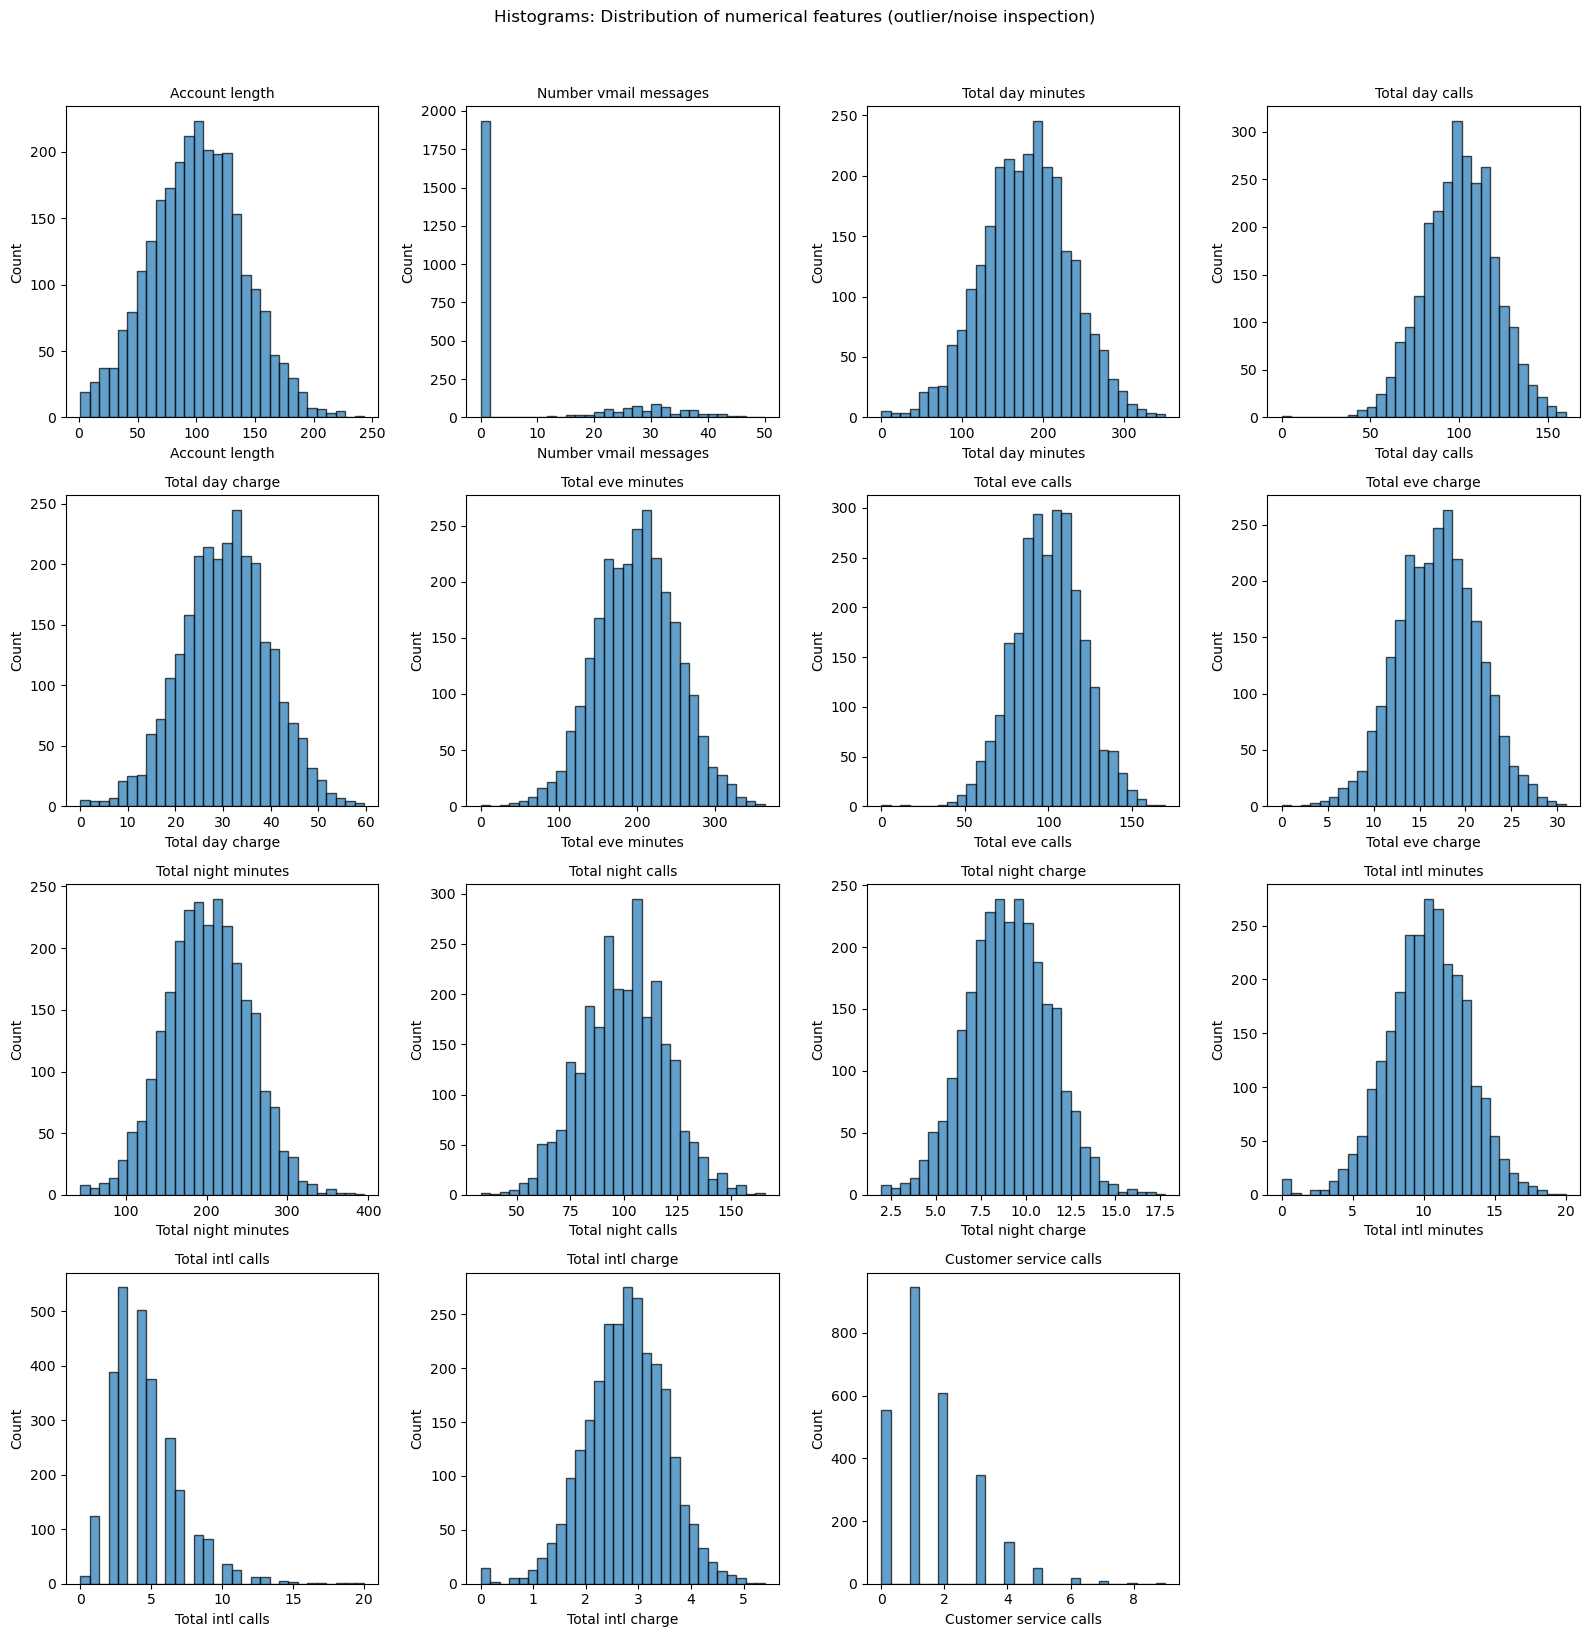

In [8]:
# Using histograms to inspect distribution of data values


# Select numerical features only (exclude categorical: Area code, State, International plan, Voice mail plan, Churn)
numerical_cols = [c for c in df.select_dtypes(include=[np.number]).columns.tolist() if c != 'Area code']

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms: Distribution of numerical features (outlier/noise inspection)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


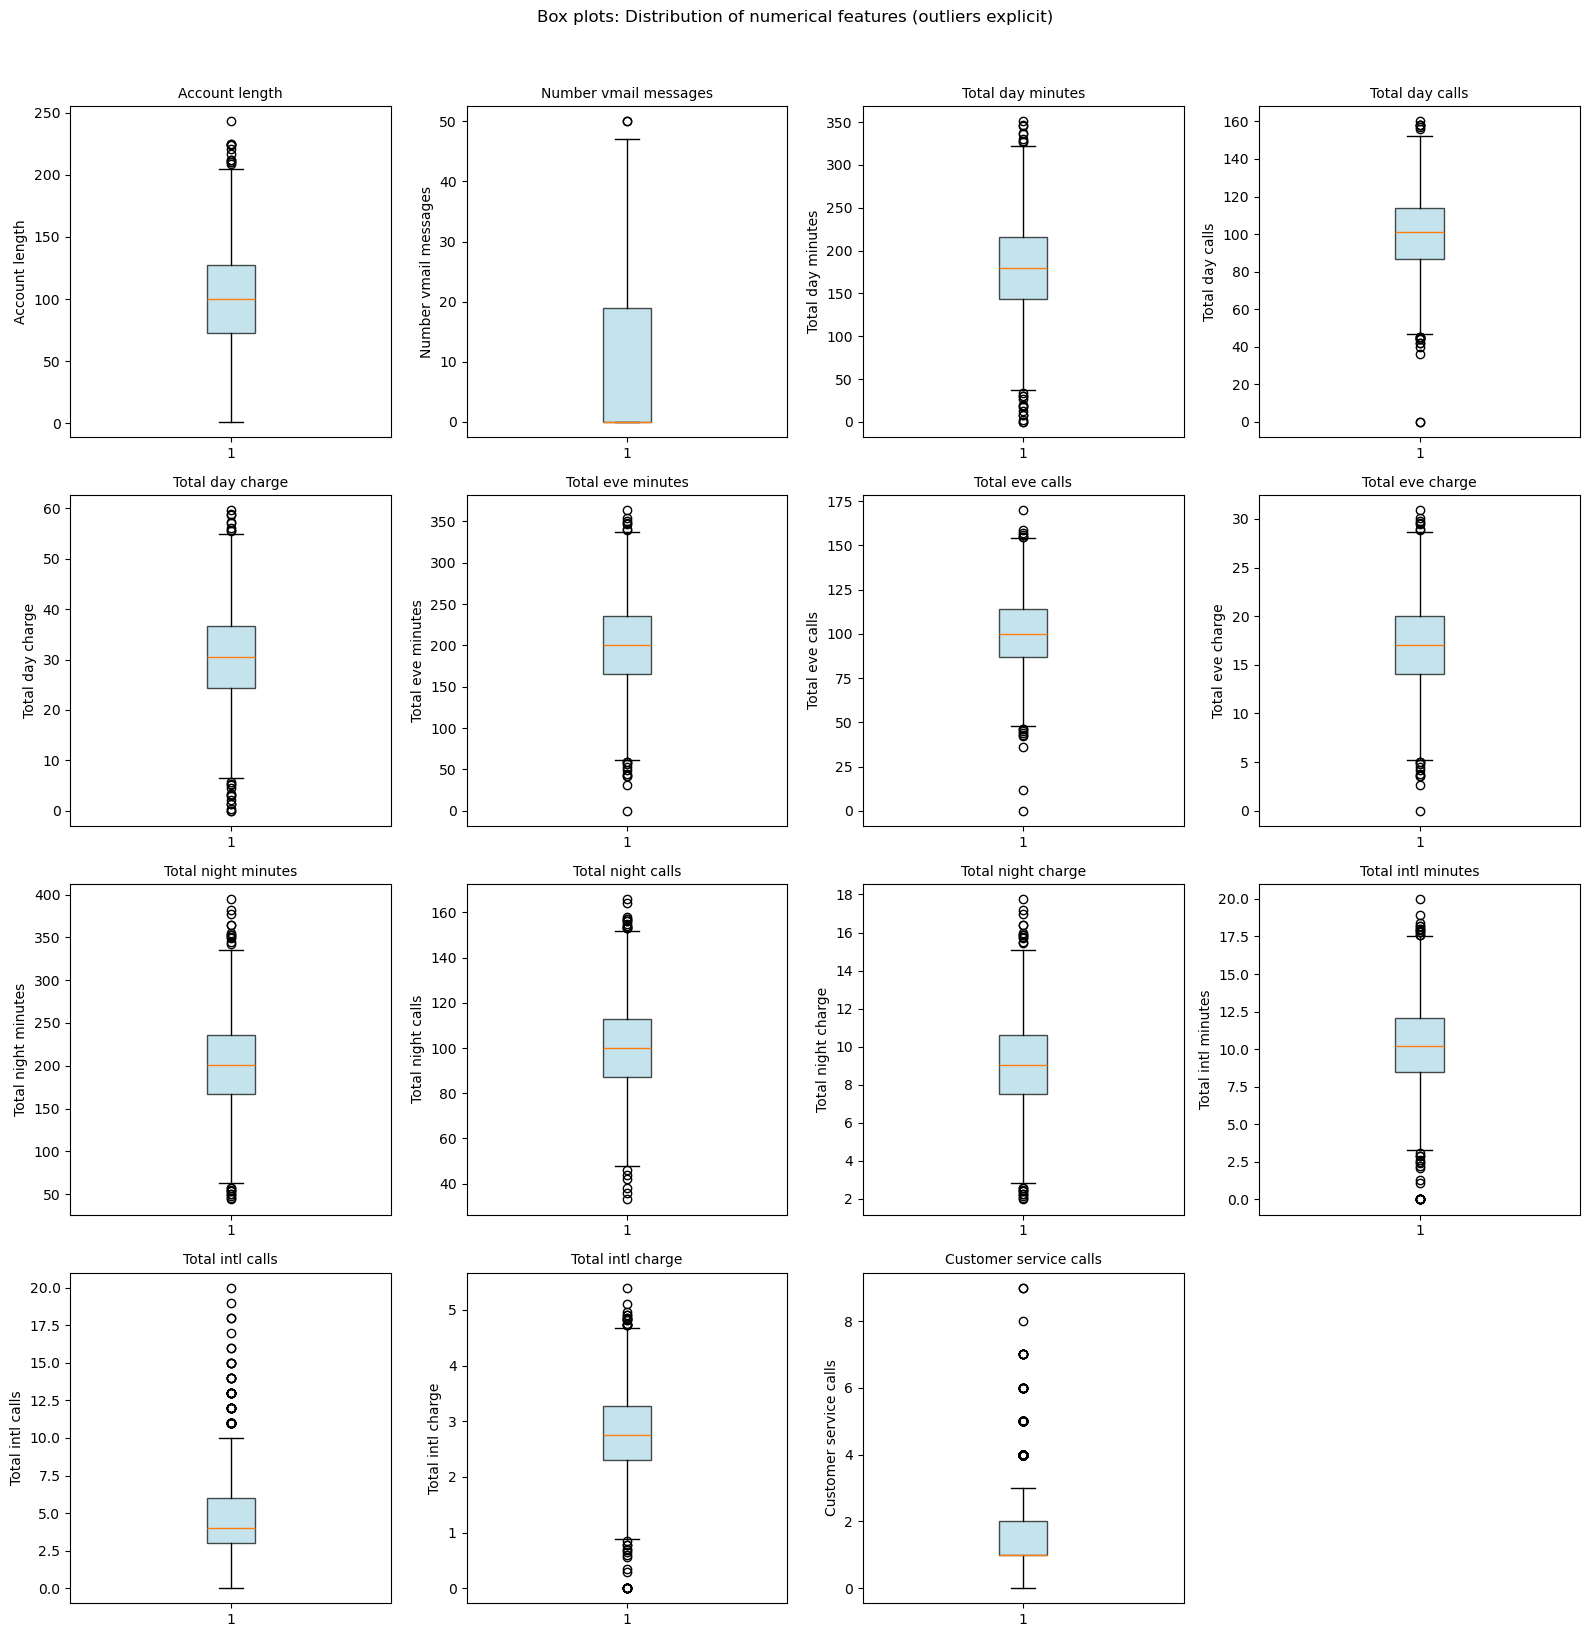

In [9]:
# Box plots to inspect distribution of attribute values - make outliers explicit
# Exclude categorical: Area code (same numerical features as histograms)
numerical_cols = [c for c in df.select_dtypes(include=[np.number]).columns.tolist() if c != 'Area code']
n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes2 = axes2.flatten()

for i, col in enumerate(numerical_cols):
    bp = axes2[i].boxplot(df[col].dropna(), vert=True, patch_artist=True)
    axes2[i].set_ylabel(col)
    axes2[i].set_title(col, fontsize=10)
    # Optional: style the box
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)

for j in range(len(numerical_cols), len(axes2)):
    axes2[j].set_visible(False)

plt.suptitle('Box plots: Distribution of numerical features (outliers explicit)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


All 'outliers' are in acceptable range. So there's no need to clean outliers.

## 2.2 Identify correlated attributes

Using scatter plot to inspect correlations

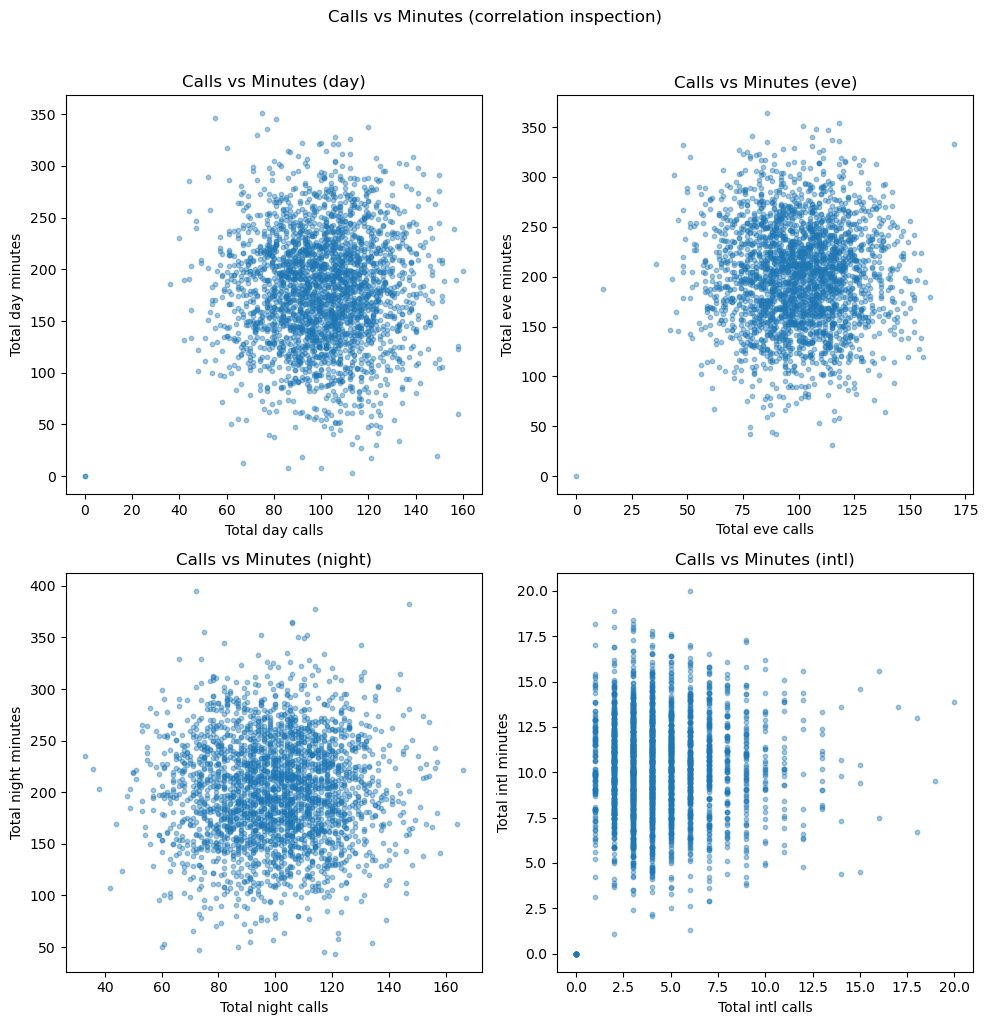

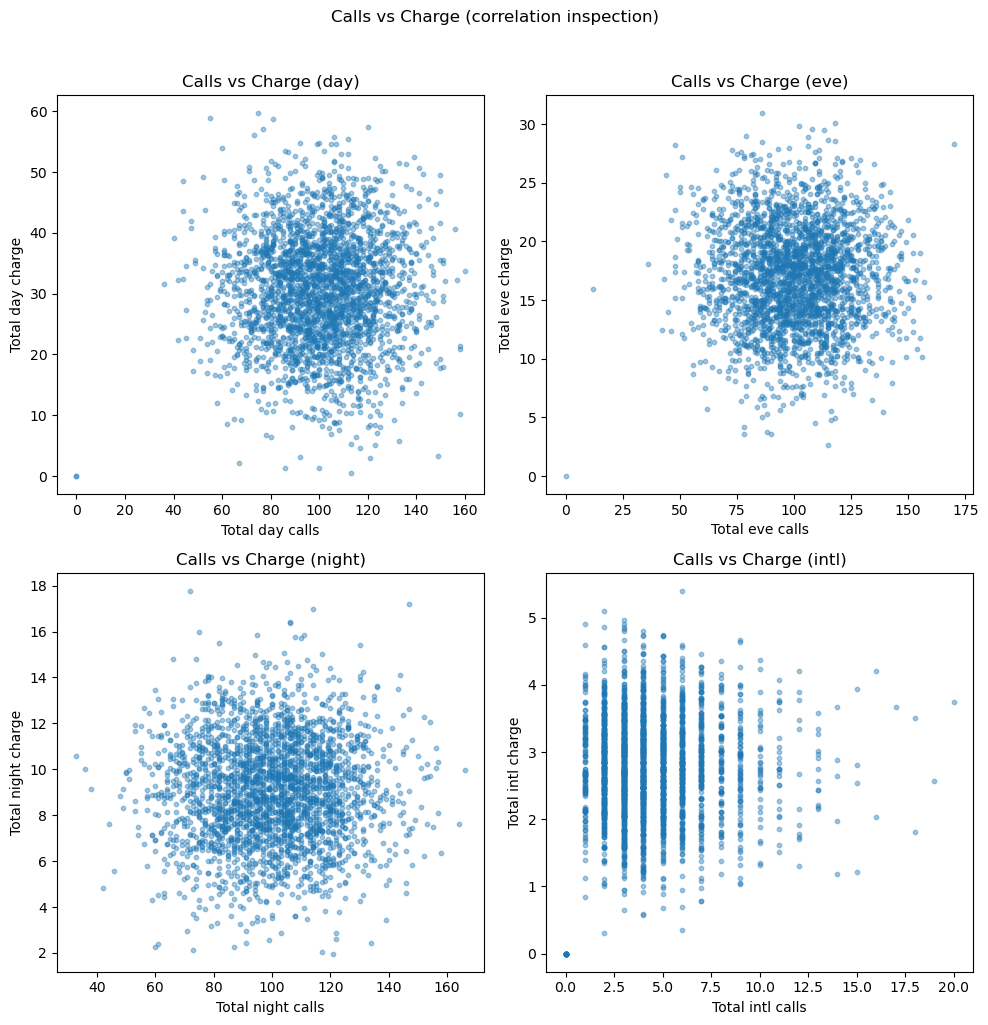

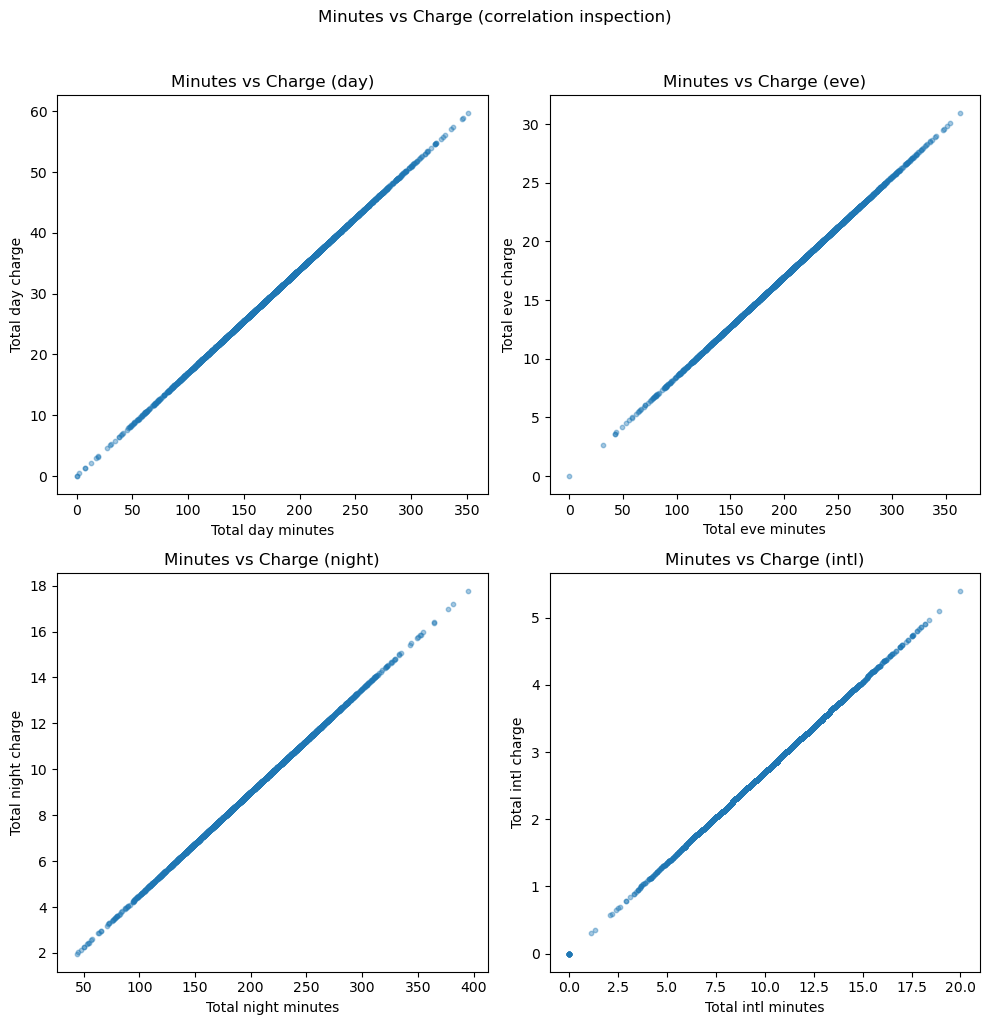

In [10]:
# Scatter plots: calls vs mins, calls vs charge, mins vs charge (by period: day, eve, night, intl)
periods = ['day', 'eve', 'night', 'intl']

# 1) Calls vs Minutes
fig1, axes1 = plt.subplots(2, 2, figsize=(10, 10))
axes1 = axes1.flatten()
for i, period in enumerate(periods):
    x_col = f'Total {period} calls'
    y_col = f'Total {period} minutes'
    axes1[i].scatter(df[x_col], df[y_col], alpha=0.4, s=10)
    axes1[i].set_xlabel(x_col)
    axes1[i].set_ylabel(y_col)
    axes1[i].set_title(f'Calls vs Minutes ({period})')
plt.suptitle('Calls vs Minutes (correlation inspection)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# 2) Calls vs Charge
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 10))
axes2 = axes2.flatten()
for i, period in enumerate(periods):
    x_col = f'Total {period} calls'
    y_col = f'Total {period} charge'
    axes2[i].scatter(df[x_col], df[y_col], alpha=0.4, s=10)
    axes2[i].set_xlabel(x_col)
    axes2[i].set_ylabel(y_col)
    axes2[i].set_title(f'Calls vs Charge ({period})')
plt.suptitle('Calls vs Charge (correlation inspection)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# 3) Minutes vs Charge
fig3, axes3 = plt.subplots(2, 2, figsize=(10, 10))
axes3 = axes3.flatten()
for i, period in enumerate(periods):
    x_col = f'Total {period} minutes'
    y_col = f'Total {period} charge'
    axes3[i].scatter(df[x_col], df[y_col], alpha=0.4, s=10)
    axes3[i].set_xlabel(x_col)
    axes3[i].set_ylabel(y_col)
    axes3[i].set_title(f'Minutes vs Charge ({period})')
plt.suptitle('Minutes vs Charge (correlation inspection)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The analysis shows that both mins and charge variables exhibit multicollinearity across all four groups of data, indicating a strong linear relationship between these features. 

However, we do not choose to remove any of these features, because high correlation does not necessarily imply redundancy, and multicollinearity does not always negatively affect model performance. 

Instead, this finding informs our subsequent model selection process, encouraging the use of models that are more robust to multicollinearity in later stages of analysis.

## 2.3 Distribution of Class Labels (Churn)

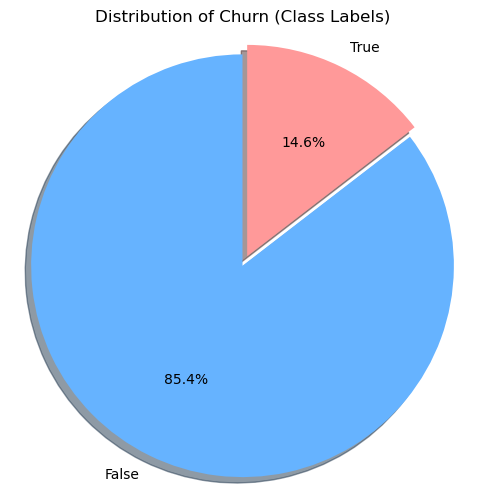

Churn value counts:
Churn
False    2278
True      388
Name: count, dtype: int64


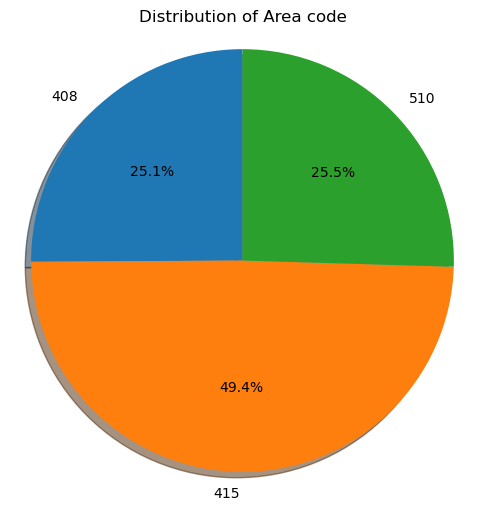

Area code value counts:
Area code
408     669
415    1318
510     679
Name: count, dtype: int64


In [11]:
# Pie chart: distribution of Churn (class labels)
churn_counts = df['Churn'].value_counts()
labels = churn_counts.index.astype(str).tolist()
sizes = churn_counts.values
colors = ['#66b3ff', '#ff9999']  # blue for False/No churn, light red for True/Churn
explode = (0, 0.05)  # slightly separate the second slice

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.title('Distribution of Churn (Class Labels)')
plt.axis('equal')
plt.show()

# Print counts for reference
print("Churn value counts:")
print(churn_counts)

# --- Area code distribution (categorical) ---
area_counts = df['Area code'].value_counts().sort_index()
plt.figure(figsize=(6, 6))
plt.pie(area_counts.values, labels=area_counts.index.astype(str), autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.title('Distribution of Area code')
plt.axis('equal')
plt.show()
print("Area code value counts:")
print(area_counts)

The result shows that the target feature - 'churn' is unbalanced. This may result the model trained from this dataset being overconfident towards majority class. 

This lead us to consider about techniques used to handle class imbalance problems, such us Label Smoothing or XGBoost.




# 4. One-Hot Coding

In [12]:
# 4.1 One-hot encoding for Area code
area_dummies = pd.get_dummies(df['Area code'], prefix='Area_code')
print("One-hot encoded columns for Area code:")
print(area_dummies.head(10))
print("\nColumn names:", area_dummies.columns.tolist())

# Option: add to dataframe (drop original Area code if replacing)
df_encoded = df.drop(columns=['Area code']).join(area_dummies)
print("\nDataFrame shape after one-hot encoding Area code:", df_encoded.shape)
print("New columns:", [c for c in df_encoded.columns if c.startswith('Area_code')])

One-hot encoded columns for Area code:
   Area_code_408  Area_code_415  Area_code_510
0          False           True          False
1          False           True          False
2          False           True          False
3           True          False          False
4          False           True          False
5          False          False           True
6          False          False           True
7          False           True          False
8          False           True          False
9          False           True          False

Column names: ['Area_code_408', 'Area_code_415', 'Area_code_510']

DataFrame shape after one-hot encoding Area code: (2666, 22)
New columns: ['Area_code_408', 'Area_code_415', 'Area_code_510']


In [13]:
df_encoded

,State,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Area_code_408,Area_code_415,Area_code_510
0,KS,128,No,Yes,25,265.1,110,45.07,197.4,99,...,91,11.01,10.0,3,2.70,1,False,False,True,False
1,OH,107,No,Yes,26,161.6,123,27.47,195.5,103,...,103,11.45,13.7,3,3.70,1,False,False,True,False
2,NJ,137,No,No,0,243.4,114,41.38,121.2,110,...,104,7.32,12.2,5,3.29,0,False,False,True,False
3,OH,84,Yes,No,0,299.4,71,50.90,61.9,88,...,89,8.86,6.6,7,1.78,2,False,True,False,False
4,OK,75,Yes,No,0,166.7,113,28.34,148.3,122,...,121,8.41,10.1,3,2.73,3,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,No,No,0,134.7,98,22.90,189.7,68,...,128,9.96,11.8,5,3.19,2,False,False,True,False
2662,AZ,192,No,Yes,36,156.2,77,26.55,215.5,126,...,83,12.56,9.9,6,2.67,2,False,False,True,False
2663,WV,68,No,No,0,231.1,57,39.29,153.4,55,...,123,8.61,9.6,4,2.59,3,False,False,True,False
2664,RI,28,No,No,0,180.8,109,30.74,288.8,58,...,91,8.64,14.1,6,3.81,2,False,False,False,True


# 5. Normalization

In [14]:
# 5. Normalization — fit scaler on TRAINING data only, then transform train & test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Binary and one-hot columns: do NOT normalize, keep original 0/1
binary_cols = ['International plan', 'Voice mail plan']
onehot_cols = [c for c in df_encoded.columns if c.startswith('Area_code')]

# Only normalize continuous numerical features (exclude binary, one-hot, target)
numerical_cols = [c for c in df.select_dtypes(include=[np.number]).columns 
                  if c not in ('Area code', 'Churn')]
if 'Churn' in numerical_cols:
    numerical_cols = [c for c in numerical_cols if c != 'Churn']
cols_to_normalize = [c for c in numerical_cols if c not in binary_cols and c not in onehot_cols]

# Convert binary to 0/1 (Yes=1, No=0) and one-hot to 0/1 for consistent output
df_processed = df_encoded.copy()
df_processed[binary_cols] = df_encoded[binary_cols].apply(lambda x: (x == 'Yes').astype(int) if x.dtype == object else x.astype(int))
df_processed[onehot_cols] = df_encoded[onehot_cols].astype(int)

X_cont = df_processed[cols_to_normalize].astype(float)
X_binary = df_processed[binary_cols]
X_onehot = df_processed[onehot_cols]
y = df_processed['Churn']

# Split indices so we can align continuous, binary, one-hot
train_idx, test_idx = train_test_split(np.arange(len(df_processed)), test_size=0.2, random_state=42)

# Fit scaler on TRAINING continuous data only
scaler = StandardScaler()
X_train_cont_norm = scaler.fit_transform(X_cont.iloc[train_idx])
X_test_cont_norm = scaler.transform(X_cont.iloc[test_idx])

# Combine: normalized continuous + binary (0/1) + one-hot (0/1)
X_train_norm = np.hstack([X_train_cont_norm, X_binary.iloc[train_idx].values, X_onehot.iloc[train_idx].values])
X_test_norm = np.hstack([X_test_cont_norm, X_binary.iloc[test_idx].values, X_onehot.iloc[test_idx].values])
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train_norm.shape, "Test shape:", X_test_norm.shape)
print("Train mean (first 5 cols):", X_train_norm[:, :5].mean(axis=0).round(4), "...")
print("Train std (first 5 cols):", X_train_norm[:, :5].std(axis=0).round(4), "...")

Train shape: (2132, 20) Test shape: (534, 20)
Train mean (first 5 cols): [-0.  0.  0. -0. -0.] ...
Train std (first 5 cols): [1. 1. 1. 1. 1.] ...


In [15]:
# Build full processed dataset (all rows): normalized continuous + binary 0/1 + one-hot 0/1
# Use the same scaler (fitted on train) to transform the entire continuous part
X_cont_full_norm = scaler.transform(X_cont)
all_features_norm = np.hstack([X_cont_full_norm, X_binary.values, X_onehot.values])

# Column names for the full feature matrix
feature_cols = cols_to_normalize + binary_cols + onehot_cols
df_final = pd.DataFrame(all_features_norm, columns=feature_cols, index=df_processed.index)
# Add Churn as 0/1 (True=1, False=0)
df_final['Churn'] = df_processed['Churn'].astype(int)

# Split into train and test processed (same split as normalization)
train_processed = df_final.iloc[train_idx]
test_processed = df_final.iloc[test_idx]

# Save all processed features to a single CSV
df_final.to_csv('full_processed.csv', index=False)
train_processed.to_csv('train_processed.csv', index=False)
test_processed.to_csv('test_processed.csv', index=False)

print("Processed features saved:")
print(f"  - full_processed.csv (full, shape: {df_final.shape})")
print(f"  - train_processed.csv (shape: {train_processed.shape})")
print(f"  - test_processed.csv (shape: {test_processed.shape})")
print("Columns:", list(df_final.columns))

Processed features saved:
  - full_processed.csv (full, shape: (2666, 21))
  - train_processed.csv (shape: (2132, 21))
  - test_processed.csv (shape: (534, 21))
Columns: ['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'International plan', 'Voice mail plan', 'Area_code_408', 'Area_code_415', 'Area_code_510', 'Churn']
